In [2]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt

**TAREA**: Sin herramientas de IA, crea una imagen, p.e. de 800x800 píxeles, con la textura del tablero de ajedrez.
Una vez resuelto de forma manual, resuelve la misma tarea usando un asistente de IA de tu elección (Claude, ChatGPT, Copilot, etc.). Compara ambas versiones en el informe de la práctica.

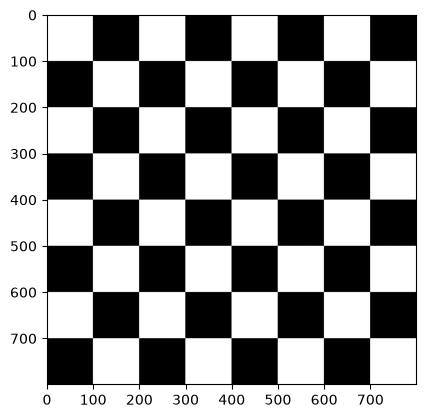

In [ ]:
# Resolucion Manual

width, height = 800, 800

gris_img = np.zeros((height,width,1), dtype = np.uint8)

gris_img

flip_color = True
for i in range(int(width / 100)):
    for j in range(int(height / 100)):
        gris_img[i*100:(i+1)*100,j*100:(j+1)*100,0] = 255 if flip_color else 0
        flip_color = not flip_color
    
    flip_color = not flip_color

plt.imshow(gris_img, cmap='gray')
plt.show()

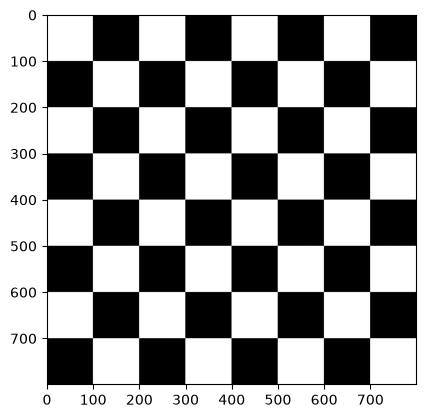

In [ ]:
ancho = 800
alto = 800
gris_img = np.random.randint(255, size=(alto, ancho, 1))
gris_img = np.zeros((alto, ancho, 1), dtype=np.uint8)
for i in range(alto):
    for j in range(ancho):
        fila = i // 100
        columna = j // 100
        if (fila + columna) % 2 == 0:
            gris_img[i, j, 0] = 255

plt.imshow(gris_img, cmap="gray") 
plt.show()

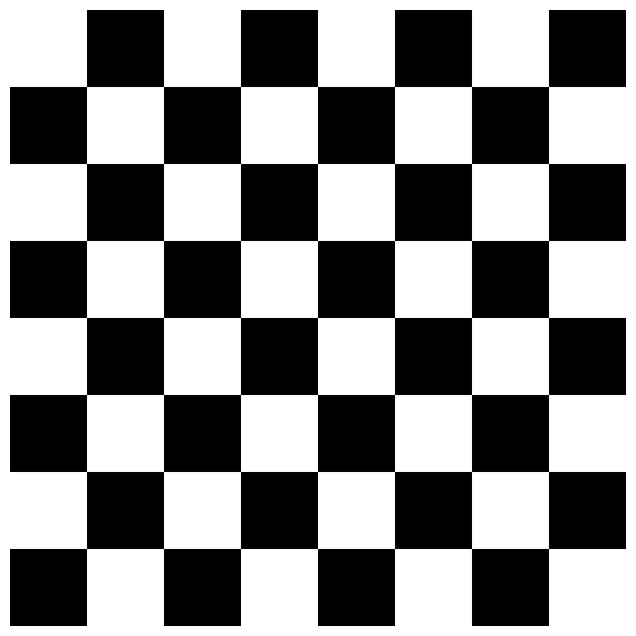

In [ ]:
# Resolucion Automática (Github Copilot - GPT 5.6 Luna)

TAMANO = 800
NUM_CASILLAS = 8
TAMANO_CASILLA = TAMANO // NUM_CASILLAS

# Crear el patrón alterno del tablero.
patron = np.indices((NUM_CASILLAS, NUM_CASILLAS)).sum(axis=0) % 2
tablero = np.kron(patron, np.ones((TAMANO_CASILLA, TAMANO_CASILLA), dtype=np.uint8))

# Convertir las casillas a blanco y negro y guardar la imagen.
imagen_tablero = np.where(tablero == 0, 255, 0).astype(np.uint8)
cv2.imwrite("tablero_ajedrez_800x800.png", imagen_tablero)

plt.figure(figsize=(8, 8))
plt.imshow(imagen_tablero, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()

**TAREA**: Crear una imagen estilo Mondrian (un ejemplo https://www3.gobiernodecanarias.org/medusa/ecoescuela/sa/2017/04/17/descubriendo-a-mondrian/) con las funciones de dibujo de OpenCV.
No hagas uso de herramientas de IA, parte del ejemplo anterior.

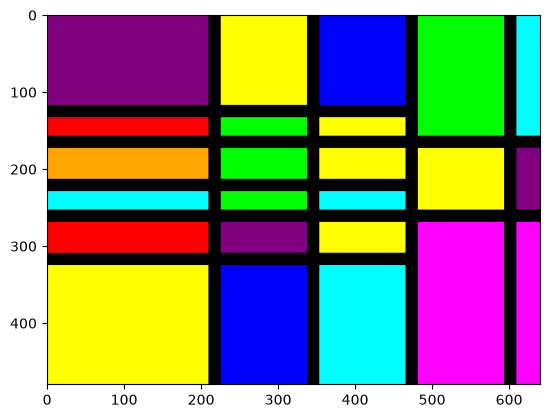

In [13]:
import random

width, height = 640, 480

total_horizontal_lines = 5
h_lines = total_horizontal_lines - random.randint((total_horizontal_lines//2)-1,(total_horizontal_lines//2)+1)
hh_lines = total_horizontal_lines - h_lines

total_vertical_lines = 5
v_lines = total_vertical_lines - random.randint((total_horizontal_lines//2)-1,(total_horizontal_lines//2)+1)
vh_lines = total_horizontal_lines - v_lines

white_img = np.ones((height, width, 3), dtype=np.uint8) * 255

# horizontal line
x = 4
horizontal_lines = []
for i in range(h_lines):
    x += width // random.randint(3,6)
    cv2.line(white_img, (x, 0), (x, height), (0, 0, 0), 15)
    horizontal_lines.append((x, 0, x, height))

# vertical line
y = 4
vertical_lines = []
for i in range(v_lines):
    y += height // random.randint(3,5)
    cv2.line(white_img, (0, y), (width, y), (0, 0, 0), 15)
    vertical_lines.append((0, y, width, y))
    
# horizontal half lines
x = 4
for i in range(hh_lines):
    x += width // random.randint(3,6)
    random_ending_line = vertical_lines[random.randint(0, len(vertical_lines) - 1)]
    starting_point = (x, 0)
    ending_point = (x, random_ending_line[1])
    cv2.line(white_img, starting_point, ending_point, (0, 0, 0), 15)
    
# vertical half lines
y = 4
for i in range(vh_lines):
    y += height // random.randint(3,5)
    random_ending_line = horizontal_lines[random.randint(0, len(horizontal_lines) - 1)]
    starting_point = (0, y)
    ending_point = (random_ending_line[0], y)
    cv2.line(white_img, starting_point, ending_point, (0, 0, 0), 15)

def find_white_rectangle(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 253, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        if np.all(image[y:y+h, x:x+w] == 255):
            return (x, y, x + w, y + h)
    
    return None    

new_image = white_img.copy()
rectangle = find_white_rectangle(new_image)
colors = [
    (255, 0, 0), # Red
    (0, 255, 0), # Green
    (0, 0, 255), # Blue
    (255, 255, 0), # Yellow
    (255, 0, 255), # Magenta
    (0, 255, 255), # Cyan
    (128, 0, 128), # Purple
    (255, 165, 0), # Orange
]

while rectangle is not None:
    x1, y1, x2, y2 = rectangle
    cv2.rectangle(new_image, (x1, y1), (x2, y2), colors[random.randint(0, len(colors) - 1)], -1)
    rectangle = find_white_rectangle(new_image)


plt.imshow(new_image, cmap='gray')
plt.show()

**TAREA**:
Pintar círculos en las posiciones del píxel más claro y oscuro de cada fotograma captado por la cámara. ¿Funciona de forma fluida o a saltos? En el segundo caso, ¿podrías acelerarlo?
Si haces uso de herramientas de IA, incluye la conversación.


In [44]:
vid = cv2.VideoCapture(0)
  
while(True):      
    ret, frame = vid.read()
    
    if ret:
        h, w, c = frame.shape
        grayscale_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        darkest_pos = np.unravel_index(np.argmin(grayscale_frame), grayscale_frame.shape)
        lightest_pos = np.unravel_index(np.argmax(grayscale_frame), grayscale_frame.shape)
        
        darkest_y, darkest_x = darkest_pos
        lightest_y, lightest_x = lightest_pos
        
        cv2.circle(frame, (darkest_x, darkest_y), 10, (0, 0, 255), 5)  # red
        cv2.circle(frame, (lightest_x, lightest_y), 10, (0, 255, 0), 5)  # green

        cv2.imshow('Two Pixel Frame', frame)
    
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
vid.release()
cv2.destroyAllWindows()

## Descripción
Esta tarea tenemos que detectar mediante la webcam que pixel es más claro y el más oscuro.

![Preview](pixel%20más%20oscuro.png)

## Análisis del código.

### Detectar pixeles claro oscuro
En este método se recibe una matriz en escala de grises, `gray` y el lienzo a color original, `frame`. Dentro de la función usamos el método `minMaxLoc` permitiendo que funcione de forma fluida, evitando al utilización de bucles para detectar los pixeles más claros o más oscuros.


[Conversación de IA](https://share.gemini.google/AOQYsRSd17rO)

In [45]:
def detectar_pixeles_claro_oscuro(gray, frame):
    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(gray)
    if min_val < 50:
        cv2.putText(frame, f"Pixel mas oscuro: {min_val}", (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        cv2.circle(frame, min_loc, 20, (255, 0, 0), 5)
    if max_val > 50:
        cv2.putText(frame, f"Pixel mas claro: {max_val}", (10, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        cv2.circle(frame, max_loc, 20, (0, 255, 0), 5)
       

vid = cv2.VideoCapture(0)
while True:
    ret, frame = vid.read()
    if ret:
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        detectar_pixeles_claro_oscuro(gray, frame)
        cv2.putText(frame, f"Azul: minimo, Verde: maximo", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        cv2.imshow("Pixeles Claro y Oscuro 1", frame)

    if cv2.waitKey(20) == 27:
        break

vid.release()
cv2.destroyAllWindows()

TAREA: Llevar a cabo una propuesta propia de pop art.
Incluye fuentes consultadas. 
Si haces uso de herramientas de IA, incluye la conversación.


## Descripción
Esta tarea decidimos inspirarnos en un efecto que tiene el movimiento Pop-Art y la estética de los cómics clásicos:

![Ejemplo de labios Pop Art](inspiración.png)

El procesamiento se divide en dos fases:
1. **Color_filter** Divide la pantalla en cuatro cuadrantes, aplicando cada uno las restricciones de canales de color RGB.
2. **Point_filter** Superone un patrón de círculos como se muestra en la imágen de referencia.

## Análisis del código.

### Color_filter
La función es la encargada de genera los cuatro cuadrante de color, sin generar imagenes nueva solo usando el fotograma original.
Cuando definimos que canales apagar se realiza en ela matriz ``[:,:, 0] = 0`` en este caso estamos apagando el canal azul, pudiendo tambien combiar los apagados del verde y rojo como ocurren en la esquina inferior izquierda dando paso el color azul.


### Point_filter

Para simular los puntos de impresión generamos una matriz blanca con el método `np.ones * 255` sobre se irá iterando para poder dibujar los puntos negros.

El valor `move` permite realizar un desplazamiento horizontalmente para recrear la textura visual de las impreisones analógicas.
| Sin el movimiento | Con el movimiento |
|:---:|:---:|
| ![Sin move](sin%20el%20move.png) | ![Con move](con%20el%20move.png) |


### ¿Cómo unimos ambos filtros?

Haremos uso de `bitwise_and` este método hace uso de operadores, en este caso el and, indicando la salida solo cuando ambas entradas tienen una salida de 255 es verdadero. Se explica mejor en este [post](https://omes-va.com/operadores-bitwise/).


In [46]:
def color_filter(frame):
        h, w= frame.shape[:2]
        
        mitad_h = int(h / 2)
        mitad_w = int(w / 2)

        tl = frame[0:mitad_h, 0:mitad_w]
        tr = frame[0:mitad_h, mitad_w:w]
        bl = frame[mitad_h:h, 0:mitad_w]
        br = frame[mitad_h:h, mitad_w:w]

        tl[:, :, 0] = 0

        tr[:, :, 0] = 0

        bl[:, :, 1] = 0
        bl[:, :, 2] = 0

        br[:, :, 0] = 0
        br[:, :, 1] = 0

def point_filter(w, h, radio, space):
    mask = np.ones((h, w, 3), dtype=np.uint8) * 255
    for y in range(0, h + space, space):
        
        move = (space // 2) if (y // space) % 2 == 1 else 0
        for x in range(0, w + space, space):
            cv2.circle(mask, (x + move, y), radio, (0, 0, 0), -1)
    
    return mask

vid = cv2.VideoCapture(0)

w = int(vid.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT))

mask = point_filter(w, h, radio=3, space=12)

while True:
    ret, frame = vid.read()
    if ret:
        color_filter(frame)
        frame_final = cv2.bitwise_and(frame, mask)
        cv2.imshow("Collage", frame_final)

    if cv2.waitKey(20) == 27:
        break
    if cv2.getWindowProperty("Collage", cv2.WND_PROP_VISIBLE) < 1:
        break


vid.release()
cv2.destroyAllWindows()

# Pop Art + ASCII

Se utiliza una table de brillo a cáracter ASCII, donde el cáracter en el índice más pequeño representa el brillo mínimo, y el final de la ristra de caracteres el brillo máximo, junto a todos sus valores intermedios.

Para minimizar la carga computacional, se precomputan en una tabla todos los valores posibles de conversión de intensidad a ASCII para solo efectuar una acción de búsqueda en el bucle principal en vez de computar cada frame individualmente.

Por último, se segmenta el frame del vídeo en 4 cuadrantes, cada uno con un color individual.

Para mejorar o reducir la calidad y precision de la imagen, se usan las variables `cell_size`, donde cuanto menor sea el numero, mayor sera la calidad y precision de la conversion de brillo y menor su rendimiento, y viceversa. La variable `cell_size` tambien se usa para computar un valor adecuado para el `font_size` de la letra ASCII a representar.

Idea de precomputación de valores de intensidad: [Gemini](https://share.gemini.google/KK4OFTzBhdzP)

In [49]:
# ASCII style effect

# Source - https://stackoverflow.com/a/74186686
# Posted by chungaloider
# Retrieved 2026-09-16, License - CC BY-SA 4.0
ascii_brightness_chars = " `.-':_,^=;><+!rc*/z?sLTv)J7(|Fi{C}fI31tlu[neoZ5Yxjya]2ESwqkP6h9d4VpOGbUAKXHm8RD#$Bg0MNWQ%&@"
ascii_brightness_values = [0, 0.0751, 0.0829, 0.0848, 0.1227, 0.1403, 0.1559, 0.185, 0.2183, 0.2417, 0.2571, 0.2852, 0.2902, 0.2919, 0.3099, 0.3192, 0.3232, 0.3294, 0.3384, 0.3609, 0.3619, 0.3667, 0.3737, 0.3747, 0.3838, 0.3921, 0.396, 0.3984, 0.3993, 0.4075, 0.4091, 0.4101, 0.42, 0.423, 0.4247, 0.4274, 0.4293, 0.4328, 0.4382, 0.4385, 0.442, 0.4473, 0.4477, 0.4503, 0.4562, 0.458, 0.461, 0.4638, 0.4667, 0.4686, 0.4693, 0.4703, 0.4833, 0.4881, 0.4944, 0.4953, 0.4992, 0.5509, 0.5567, 0.5569, 0.5591, 0.5602, 0.5602, 0.565, 0.5776, 0.5777, 0.5818, 0.587, 0.5972, 0.5999, 0.6043, 0.6049, 0.6093, 0.6099, 0.6465, 0.6561, 0.6595, 0.6631, 0.6714, 0.6759, 0.6809, 0.6816, 0.6925, 0.7039, 0.7086, 0.7235, 0.7302, 0.7332, 0.7602, 0.7834, 0.8037, 0.9999]

assert len(ascii_brightness_chars) == len(ascii_brightness_values), "The length of ascii_brightness_chars and ascii_brightness_values must be the same."

# https://medium.com/@aditiverma00300/ascii-style-image-7d75f5d0b019
def intensity_to_ascii(intensity):
    index = int(intensity / 255.0 * (len(ascii_brightness_chars) - 1))
    return ascii_brightness_chars[index]

def intensity_to_ascii(intensity):
    normalized_intensity = intensity / 255.0
    closest_index = min(range(len(ascii_brightness_values)), key=lambda i: abs(ascii_brightness_values[i] - normalized_intensity))
    return ascii_brightness_chars[closest_index]

ascii_intensity_table = []
for i in range(256):
    ascii_intensity_table.append(intensity_to_ascii(i))
    
def cell_size_to_font_scale(cell_size):
    return float(cell_size / 30.0)

vid = cv2.VideoCapture(0)
cell_size = 12
font_scale = cell_size_to_font_scale(cell_size)
while True:
    ret, frame = vid.read()

    if not ret:
        break
    
    h, w, c = frame.shape
    grid_w = w // cell_size
    grid_h = h // cell_size
    
    down_frame = cv2.resize(frame, (grid_w, grid_h), interpolation=cv2.INTER_AREA)
    gray_frame = cv2.cvtColor(down_frame, cv2.COLOR_BGR2GRAY)
    ascii_frame = np.zeros((h, w, 3), dtype=np.uint8)
    
    for i in range(grid_h):
        for j in range(grid_w):
            char = ascii_intensity_table[gray_frame[i, j]]
            x = j * cell_size
            y = (i+1) * cell_size

            if x < w // 2 and y < h // 2:
                character_color = (0, 0, 255) # top-left
            elif x >= w // 2 and y < h // 2:
                character_color = (0, 255, 0) # top-right
            elif x < w // 2 and y >= h // 2:
                character_color = (255, 0, 0) # bottom-left
            else:
                character_color = (0, 255, 255) # bottom-right

            cv2.putText(ascii_frame, char, (x, y), cv2.FONT_HERSHEY_SIMPLEX, font_scale, character_color, 1, cv2.LINE_AA)
            

    cv2.imshow('ASCII Pop Art Effect', ascii_frame)
    
    if cv2.waitKey(1) == 27:  # Exit on ESC key
        break


vid.release()
cv2.destroyAllWindows()